# Tail-Aware Residual Alpha Engine — F0d: Pre-Registered Hidden-Risk Test

**The H2 detector has never engaged on real data — by construction, not by failure.** F0/F0b/F0c found no surviving alpha in residual momentum across mega-, mid-, and small-cap (all `H3`), and `H2` can only fire on a strategy that **passes the luck gate first**. So we never saw whether the referee, faced with a *profitable* strategy that is secretly a risk premium, would correctly flag it.

**F0d tests exactly that — honestly.** The temptation would be to keep hunting universes until an `H2` appears; that is the p-hacking the whole project is built to resist. Instead we **declare, ex ante, two strategies that harvest known hidden-risk premia** and ask whether the frozen referee classifies them correctly. This is the real-data analog of the synthetic H2 validation: the detector was built and calibrated against a synthetic hidden crash factor; now we hand it real strategies engineered to carry hidden risk.

**The residualization subtlety (this is the crux).** A strategy that co-crashes with the market via ordinary market beta has its return *removed* by linear residualization → it would show as `H3`, not `H2`. To survive residualization yet carry crash risk, the exposure must be **nonlinear** — orthogonal to linear factors. That is precisely the synthetic hidden-crash setup (a factor with near-zero variance except in episodes), and its cleanest real-data analog is the **downside-risk premium** (Ang–Chen–Xing 2006): the part of beta that appears *only in market-tail days*.

**Two pre-registered strategies:**
- **S1_downside_risk** — long high `(downside-beta − plain-beta)`, short low. The sort variable is the nonlinear tail amplification, ~orthogonal to plain beta, so the premium survives linear residualization while the strategy co-crashes with the market. **Pre-registered:** passes the luck gate **and** ≥2 tail conditions fire → `H2`.
- **S2_lowvol** — long low idiosyncratic vol, short high (the low-volatility anomaly). A hidden-risk premium of a *different archetype*: it crashes in junk-rallies (market **up**), not market co-crashes. **Pre-registered:** may pass the luck gate but fires *fewer* of the market-co-crash-tuned conditions → probes cross-archetype generalization.

### Demo vs real
Delivered in **DEMO mode** (`data_source='shaped'`, offline): the synthetic panel has a downside-risk premium baked in, so S1 should come out `H2` — proving the pipeline can deliver an `H2` and that the referee does **not** certify a profitable-but-co-crashing strategy as alpha. **For the real test, set `data_source='yfinance'` and Run All on Colab.** The open empirical question: does the *real* downside-risk premium in the S&P 500 earn enough to pass the luck gate while co-crashing → the first **real** `H2`?

In [1]:
# ============================================================
# Tail-Aware Residual Alpha Engine - F0d: Pre-Registered Hidden-Risk Test
# Replication anchor: Blitz-Huij-Martens residual momentum
# Referee: FROZEN V1.4 graded four-state verdict machinery
# ============================================================
# F0/F0b/F0c found NO surviving alpha in residual momentum across the
# size spectrum (all H3), so the H2 detector never engaged - it can only
# fire on a strategy that PASSES the luck gate first. F0d is the honest
# way to test H2: instead of searching universes until H2 appears (which
# would be the p-hacking the whole project guards against), we DECLARE
# EX-ANTE two strategies that harvest KNOWN hidden-risk premia, and test
# whether the frozen referee flags them correctly. Pre-registered below.
# PUBLIC-DATA PROTOTYPE; survivorship caveat as in F0b.
import io
import math
import zipfile
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RNG_SEED = 42
np.random.seed(RNG_SEED)

CONFIG = {
    'start': '2007-01-01',
    'end': '2024-12-31',
    'data_source': 'yfinance',        # 'yfinance' on Colab; 'shaped' for offline pipeline test
    'rf_annual_fallback': 0.0,
    # residualization
    'beta_lookback': 252,             # trailing window for FF beta estimation
    'beta_refit_every': 21,           # re-estimate betas monthly, hold within month
    'pca_k': 3,                       # PCs removed at L3
    # signals (BHM residual momentum: ~12-1, daily-held)
    'mom_lookback': 252, 'mom_skip': 21,
    'rev_lookback': 5, 'rev_skip': 1, 'rev_drift_window': 58,
    'rebalance': 21,                  # monthly formation, daily hold
    # portfolio
    'top_q': 0.20, 'bottom_q': 0.20, 'min_side': 8,
    'cost_bps': 10.0,                 # one-way, bps (real large-cap)
    'annualization': 252,
    'nw_lags_daily': 21,
    # luck layer
    'placebo_n': 100,            # 1% percentile resolution on the 97.5 gate; raise on Colab if desired
    'n_trials_declared': 8,           # real-data configs evaluated here (4 levels x 2 signals)
    'verdict_level': 'L2_FF3',
    # ---- FROZEN V1.4 REFEREE RULES (verbatim from the synthetic suite) ----
    'luck_rule': {'placebo_pct_min': 97.5, 'dsr_z_min': 0.0},
    # V1.3: cdar_beta_min raised 0.5 -> 0.75. The V1.2 MC measured 19-25%
    # false fires of this condition on clean worlds (it was the noisy one);
    # recalibrated on the training seed range, frozen before held-out validation.
    # V1.4: graded tail battery. Each metric scores 0 (clean) / 1 (soft) / 2 (hard).
    # The V1.3 held-out MC measured an 8% dangerous rate (hidden crash certified as
    # H1); those cases were the MILD tail of a continuum - genuinely loading on the
    # crash factor and losing on crash days, but with realized tail signatures just
    # below every hard threshold. A graded score that quarantines on ACCUMULATED soft
    # evidence (>=2 soft points) catches them at a far smaller detection cost than
    # tightening the hard thresholds. Soft thresholds and score cuts were selected on
    # the burned design set (training+validation, 200 seeds) and frozen before the
    # V1.4 held-out validation on a virgin seed range.
    'tail_rule': {'downside_gap_min': 0.25, 'skew_max': -1.0,
                  'cdar_beta_min': 0.75, 'coskew_max': -0.20,
                  'downside_gap_soft': 0.125, 'skew_soft': -0.50,
                  'cdar_beta_soft': 0.50, 'coskew_soft': -0.10,
                  'min_hard_conditions': 2, 'h2_score': 4, 'h1_score_max': 1},
}

# current S&P 500 (hardcoded for reproducibility; survivorship caveat above).
# Source: github datasets/s-and-p-500-companies, normalized for yfinance ('.'->'-').
UNIVERSE = [
 'MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A', 'APD', 'ABNB', 'AKAM',
 'ALB', 'ARE', 'ALGN', 'ALLE', 'LNT', 'ALL', 'GOOGL', 'GOOG', 'MO', 'AMZN', 'AMCR', 'AEE', 'AEP',
 'AXP', 'AIG', 'AMT', 'AWK', 'AMP', 'AME', 'AMGN', 'APH', 'ADI', 'AON', 'APA', 'APO', 'AAPL',
 'AMAT', 'APP', 'APTV', 'ACGL', 'ADM', 'ARES', 'ANET', 'AJG', 'AIZ', 'T', 'ATO', 'ADSK', 'ADP',
 'AZO', 'AVB', 'AVY', 'AXON', 'BKR', 'BALL', 'BAC', 'BAX', 'BDX', 'BRK-B', 'BBY', 'TECH', 'BIIB',
 'BLK', 'BX', 'XYZ', 'BNY', 'BA', 'BKNG', 'BSX', 'BMY', 'AVGO', 'BR', 'BRO', 'BF-B', 'BLDR',
 'BG', 'BXP', 'CHRW', 'CDNS', 'CPT', 'CPB', 'COF', 'CAH', 'CCL', 'CARR', 'CVNA', 'CASY', 'CAT',
 'CBOE', 'CBRE', 'CDW', 'COR', 'CNC', 'CNP', 'CF', 'CRL', 'SCHW', 'CHTR', 'CVX', 'CMG', 'CB',
 'CHD', 'CIEN', 'CI', 'CINF', 'CTAS', 'CSCO', 'C', 'CFG', 'CLX', 'CME', 'CMS', 'KO', 'CTSH',
 'COHR', 'COIN', 'CL', 'CMCSA', 'FIX', 'CAG', 'COP', 'ED', 'STZ', 'CEG', 'COO', 'CPRT', 'GLW',
 'CPAY', 'CTVA', 'CSGP', 'COST', 'CRH', 'CRWD', 'CCI', 'CSX', 'CMI', 'CVS', 'DHR', 'DRI', 'DDOG',
 'DVA', 'DECK', 'DE', 'DELL', 'DAL', 'DVN', 'DXCM', 'FANG', 'DLR', 'DG', 'DLTR', 'D', 'DPZ',
 'DASH', 'DOV', 'DOW', 'DHI', 'DTE', 'DUK', 'DD', 'ETN', 'EBAY', 'SATS', 'ECL', 'EIX', 'EW',
 'EA', 'ELV', 'EME', 'EMR', 'ETR', 'EOG', 'EQT', 'EFX', 'EQIX', 'EQR', 'ERIE', 'ESS', 'EL',
 'EG', 'EVRG', 'ES', 'EXC', 'EXE', 'EXPE', 'EXPD', 'EXR', 'XOM', 'FFIV', 'FDS', 'FICO', 'FAST',
 'FRT', 'FDX', 'FDXF', 'FIS', 'FITB', 'FSLR', 'FE', 'FISV', 'F', 'FTNT', 'FTV', 'FOXA', 'FOX',
 'BEN', 'FCX', 'GRMN', 'IT', 'GE', 'GEHC', 'GEV', 'GEN', 'GNRC', 'GD', 'GIS', 'GM', 'GPC',
 'GILD', 'GPN', 'GL', 'GDDY', 'GS', 'HAL', 'HIG', 'HAS', 'HCA', 'DOC', 'HSIC', 'HSY', 'HPE',
 'HLT', 'HD', 'HON', 'HRL', 'HST', 'HWM', 'HPQ', 'HUBB', 'HUM', 'HBAN', 'HII', 'IBM', 'IEX',
 'IDXX', 'ITW', 'INCY', 'IR', 'PODD', 'INTC', 'IBKR', 'ICE', 'IFF', 'IP', 'INTU', 'ISRG', 'IVZ',
 'INVH', 'IQV', 'IRM', 'JBHT', 'JBL', 'JKHY', 'J', 'JNJ', 'JCI', 'JPM', 'KVUE', 'KDP', 'KEY',
 'KEYS', 'KMB', 'KIM', 'KMI', 'KKR', 'KLAC', 'KHC', 'KR', 'LHX', 'LH', 'LRCX', 'LVS', 'LDOS',
 'LEN', 'LII', 'LLY', 'LIN', 'LYV', 'LMT', 'L', 'LOW', 'LULU', 'LITE', 'LYB', 'MTB', 'MPC',
 'MAR', 'MRSH', 'MLM', 'MAS', 'MA', 'MKC', 'MCD', 'MCK', 'MDT', 'MRK', 'META', 'MET', 'MTD',
 'MGM', 'MCHP', 'MU', 'MSFT', 'MAA', 'MRNA', 'TAP', 'MDLZ', 'MPWR', 'MNST', 'MCO', 'MS', 'MOS',
 'MSI', 'MSCI', 'NDAQ', 'NTAP', 'NFLX', 'NEM', 'NWSA', 'NWS', 'NEE', 'NKE', 'NI', 'NDSN', 'NSC',
 'NTRS', 'NOC', 'NCLH', 'NRG', 'NUE', 'NVDA', 'NVR', 'NXPI', 'ORLY', 'OXY', 'ODFL', 'OMC', 'ON',
 'OKE', 'ORCL', 'OTIS', 'PCAR', 'PKG', 'PLTR', 'PANW', 'PSKY', 'PH', 'PAYX', 'PYPL', 'PNR', 'PEP',
 'PFE', 'PCG', 'PM', 'PSX', 'PNW', 'PNC', 'POOL', 'PPG', 'PPL', 'PFG', 'PG', 'PGR', 'PLD',
 'PRU', 'PEG', 'PTC', 'PSA', 'PHM', 'PWR', 'QCOM', 'DGX', 'Q', 'RL', 'RJF', 'RTX', 'O',
 'REG', 'REGN', 'RF', 'RSG', 'RMD', 'RVTY', 'HOOD', 'ROK', 'ROL', 'ROP', 'ROST', 'RCL', 'SPGI',
 'CRM', 'SNDK', 'SBAC', 'SLB', 'STX', 'SRE', 'NOW', 'SHW', 'SPG', 'SWKS', 'SJM', 'SW', 'SNA',
 'SOLV', 'SO', 'LUV', 'SWK', 'SBUX', 'STT', 'STLD', 'STE', 'SYK', 'SMCI', 'SYF', 'SNPS', 'SYY',
 'TMUS', 'TROW', 'TTWO', 'TPR', 'TRGP', 'TGT', 'TEL', 'TDY', 'TER', 'TSLA', 'TXN', 'TPL', 'TXT',
 'TMO', 'TJX', 'TKO', 'TTD', 'TSCO', 'TT', 'TDG', 'TRV', 'TRMB', 'TFC', 'TYL', 'TSN', 'USB',
 'UBER', 'UDR', 'ULTA', 'UNP', 'UAL', 'UPS', 'URI', 'UNH', 'UHS', 'VLO', 'VEEV', 'VTR', 'VLTO',
 'VRSN', 'VRSK', 'VZ', 'VRTX', 'VRT', 'VTRS', 'VICI', 'V', 'VST', 'VMC', 'WRB', 'GWW', 'WAB',
 'WMT', 'DIS', 'WBD', 'WM', 'WAT', 'WEC', 'WFC', 'WELL', 'WST', 'WDC', 'WY', 'WSM', 'WMB',
 'WTW', 'WDAY', 'WYNN', 'XEL', 'XYL', 'YUM', 'ZBRA', 'ZBH', 'ZTS']
print('F0b config initialized. Universe:', len(UNIVERSE), 'names |', CONFIG['start'], '->', CONFIG['end'])
print('Referee: FROZEN V1.4 (luck gate + graded tail score), verdict level', CONFIG['verdict_level'])

F0b config initialized. Universe: 503 names | 2007-01-01 -> 2024-12-31
Referee: FROZEN V1.4 (luck gate + graded tail score), verdict level L2_FF3


## 1. Data loading — Colab (yfinance + Ken French) or offline (shaped)

Same loader as F0b (S&P 500, hardcoded tickers, Ken French daily-factor ZIP). The **shaped** panel additionally injects a downside-risk premium: each stock gets a nonlinear downside amplification `delta` (orthogonal to mean/linear beta) — it earns a constant carry per unit `delta` and amplifies losses on market-tail days. A strategy long high-`delta` therefore earns a premium that survives linear residualization yet co-crashes — the H2 archetype, so the demo exercises the full H2 verdict path.

In [2]:
# ============================================================
# 1. Data loading
#    Colab path: yfinance prices + Ken French daily factors.
#    Offline path ('shaped'): realistic synthetic panel with a
#    2009-style momentum crash, so the H2 tail detector is
#    exercised on a known-crash environment without real data.
# ============================================================
FF_DAILY_URL = ('https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/'
                'F-F_Research_Data_Factors_daily_CSV.zip')
FF_MOM_URL = ('https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/'
              'F-F_Momentum_Factor_daily_CSV.zip')

def _parse_ff_zip(raw_bytes, value_cols):
    """Parse a Ken French daily-factor CSV zip into a DataFrame indexed by date.
    Robust to the header preamble and the annual-data footer."""
    zf = zipfile.ZipFile(io.BytesIO(raw_bytes))
    name = [n for n in zf.namelist() if n.lower().endswith('.csv')][0]
    text = zf.read(name).decode('latin-1').splitlines()
    rows = []
    for ln in text:
        parts = [p.strip() for p in ln.split(',')]
        if len(parts) >= 2 and parts[0].isdigit() and len(parts[0]) == 8:
            rows.append(parts)
    df = pd.DataFrame(rows).set_index(0)
    df.index = pd.to_datetime(df.index, format='%Y%m%d')
    df = df.iloc[:, :len(value_cols)].astype(float) / 100.0
    df.columns = value_cols
    return df

def fetch_ff_factors():
    base = _parse_ff_zip(urllib.request.urlopen(FF_DAILY_URL, timeout=60).read(),
                         ['MKT', 'SMB', 'HML', 'RF'])
    try:
        mom = _parse_ff_zip(urllib.request.urlopen(FF_MOM_URL, timeout=60).read(), ['MOM'])
        base = base.join(mom, how='left')
    except Exception as e:
        print('  (momentum factor fetch failed, proceeding without MOM):', str(e)[:60])
        base['MOM'] = np.nan
    return base

def fetch_prices_yf(tickers, start, end):
    import yfinance as yf
    raw = yf.download(tickers, start=start, end=end, auto_adjust=True,
                      progress=False, group_by='column')
    close = raw['Close'] if isinstance(raw.columns, pd.MultiIndex) else raw.to_frame()
    close = close.dropna(axis=1, how='all')
    keep = close.columns[close.notna().sum() >= 252]
    return close[keep]

def make_shaped_panel(cfg, n_stocks=500, seed=7):
    """Offline realistic panel: fat-tailed factors with 2008/2020 crashes, a
    persistent momentum structure, and a March-2009-style momentum crash where
    prior losers violently rebound. Returns (prices, ff) shaped like the real ones."""
    rng = np.random.default_rng(seed)
    dates = pd.bdate_range(cfg['start'], cfg['end'])
    T = len(dates)
    # market with fat tails + targeted crash windows
    mkt = rng.standard_t(5, T) * 0.009
    def window(s, e):
        a = (dates >= s) & (dates <= e)
        return np.where(a)[0]
    mkt[window('2008-09-15', '2008-11-20')] += rng.normal(-0.010, 0.02, len(window('2008-09-15','2008-11-20')))
    mkt[window('2020-02-20', '2020-03-23')] += rng.normal(-0.012, 0.025, len(window('2020-02-20','2020-03-23')))
    smb = rng.standard_t(6, T) * 0.004
    hml = rng.standard_t(6, T) * 0.004
    rf = np.full(T, 0.01/252)
    ff = pd.DataFrame({'MKT': mkt, 'SMB': smb, 'HML': hml, 'RF': rf,
                       'MOM': np.zeros(T)}, index=dates)
    # stock betas and persistent idiosyncratic momentum factor
    bm = rng.normal(1.0, 0.25, n_stocks)
    bs = rng.normal(0.0, 0.3, n_stocks)
    bh = rng.normal(0.0, 0.3, n_stocks)
    # slow idiosyncratic trend (creates cross-sectional momentum)
    lat = np.zeros((T, n_stocks))
    shock = rng.normal(0, 0.00015, (T, n_stocks))
    for t in range(1, T):
        lat[t] = 0.99 * lat[t-1] + shock[t]
    idio = rng.standard_t(5, (T, n_stocks)) * 0.014
    rets = (bm[None,:]*mkt[:,None] + bs[None,:]*smb[:,None] + bh[None,:]*hml[:,None]
            + lat + idio + rf[:,None])
    # --- DOWNSIDE-RISK PREMIUM (for F0d): some stocks carry extra crash exposure ---
    # delta_j = nonlinear downside amplification (orthogonal to mean/linear beta).
    # They earn a constant carry (compensation) AND amplify losses on market-down
    # days (co-crash). A strategy long high-delta / short low-delta thus earns a
    # premium that SURVIVES linear residualization yet co-crashes -> the H2 archetype.
    delta = rng.uniform(0.0, 1.0, n_stocks)
    rets += (0.0020 * delta)[None, :]                       # constant carry per unit delta
    downd = mkt <= np.quantile(mkt, 0.10)                    # market-tail days
    rets[np.ix_(np.where(downd)[0], np.arange(n_stocks))] += (
        np.outer(mkt[downd], delta) * 0.7)                   # extra downside beta on tail days
    meta_delta = delta
    # March-2009-style momentum crash: prior 12m losers rebound hard for ~6 weeks
    form = window('2008-02-01', '2009-02-27')
    crash = window('2009-03-02', '2009-04-15')
    if len(form) > 20 and len(crash) > 0:
        prior = rets[form].sum(axis=0)
        loser = prior < np.quantile(prior, 0.3)
        rets[np.ix_(crash, loser)] += 0.006      # losers spike -> momentum crashes
        rets[np.ix_(crash, ~loser)] -= 0.0020
    prices = pd.DataFrame(100*np.cumprod(1+rets, axis=0), index=dates,
                          columns=[f'S{i:03d}' for i in range(n_stocks)])
    # momentum factor proxy for completeness
    ff['MOM'] = pd.Series(np.r_[0, np.diff(np.log(prices.mean(axis=1)))], index=dates).fillna(0).values
    return prices, ff

def load_panel(cfg):
    if cfg['data_source'] == 'shaped':
        prices, ff = make_shaped_panel(cfg)
        print(f'  [shaped] {prices.shape[1]} stocks x {prices.shape[0]} days (offline pipeline test)')
    else:
        print('  fetching Ken French daily factors ...')
        ff = fetch_ff_factors()
        print('  fetching prices via yfinance ...')
        prices = fetch_prices_yf(UNIVERSE, cfg['start'], cfg['end'])
        idx = prices.index.intersection(ff.index)
        prices, ff = prices.loc[idx], ff.loc[idx]
        print(f'  fetched {prices.shape[1]} stocks x {prices.shape[0]} days')
    return prices, ff

## 2. Returns and excess returns

Daily simple returns from adjusted closes; excess over the daily risk-free rate. Thin/missing names dropped.

In [3]:
# ============================================================
# 2. Returns and excess returns
# ============================================================
def build_returns(prices, ff, cfg):
    rets = prices.pct_change()
    # keep days with enough cross-section
    rets = rets[rets.notna().sum(axis=1) >= cfg['min_side'] * 2]
    ff = ff.reindex(rets.index)
    excess = rets.sub(ff['RF'], axis=0)
    return rets, excess, ff
print('Returns builder defined.')

Returns builder defined.


## 3. Rolling per-stock risk estimates

At each monthly refit, on a trailing 252-day window: **plain beta** (vs market), **downside beta** (market-tail days, worst 30% of the window), and **idiosyncratic volatility** (std of the FF residual). These feed the two declared signals. Estimates are held within the month and applied forward — past-measurable only.

In [4]:
# ============================================================
# 3. Rolling per-stock risk estimates (monthly refit, trailing 252d)
#    plain beta, downside beta (market-tail days), idiosyncratic vol.
#    These feed the two declared hidden-risk-harvesting signals.
# ============================================================
def rolling_stock_estimates(excess, ff, cfg):
    idx = excess.index; n = len(idx); L = cfg['beta_lookback']; step = cfg['beta_refit_every']
    mkt = ff['MKT'].values; Ff = ff[['MKT', 'SMB', 'HML']].values
    plain_beta = pd.DataFrame(np.nan, index=idx, columns=excess.columns)
    down_beta = pd.DataFrame(np.nan, index=idx, columns=excess.columns)
    idio_vol = pd.DataFrame(np.nan, index=idx, columns=excess.columns)
    cols = excess.values
    for r0 in range(L, n, step):
        w = slice(r0 - L, r0); fwd = slice(r0, min(r0 + step, n))
        mw = mkt[w]; Fw = Ff[w]
        okF = np.isfinite(Fw).all(axis=1) & np.isfinite(mw)
        thr = np.nanquantile(mw[okF], 0.30) if okF.sum() > 20 else np.nan
        down = okF & (mw <= thr)
        vmw = np.var(mw[okF]) if okF.sum() > 2 else np.nan
        vmd = np.var(mw[down]) if down.sum() > 2 else np.nan
        for j in range(cols.shape[1]):
            yw = cols[w, j]; m = np.isfinite(yw) & okF
            if m.sum() < L // 2 or not (vmw > 0):
                continue
            plain_beta.iloc[fwd, j] = np.cov(yw[m], mw[m])[0, 1] / vmw
            md = m & down
            if md.sum() > 20 and vmd > 0:
                down_beta.iloc[fwd, j] = np.cov(yw[md], mw[md])[0, 1] / vmd
            A = np.column_stack([np.ones(m.sum()), Fw[m]])
            bF, *_ = np.linalg.lstsq(A, yw[m], rcond=None)
            idio_vol.iloc[fwd, j] = (yw[m] - A @ bF).std()
    return {'plain_beta': plain_beta, 'down_beta': down_beta, 'idio_vol': idio_vol}
print('Rolling stock-risk estimates defined.')

Rolling stock-risk estimates defined.


## 4. Two pre-registered hidden-risk harvesters

S1 sorts on `downside-beta − plain-beta` (the tail amplification that survives linear residualization); S2 sorts on `−idiosyncratic-vol` (the low-vol anomaly). Both cross-sectionally standardized. The hypotheses above were fixed before running; the verdicts below are read against them.

In [5]:
# ============================================================
# 4. Two PRE-REGISTERED hidden-risk-premium harvesters
# ------------------------------------------------------------
#  S1_downside_risk : long high (downside_beta - plain_beta), short low.
#    Harvests the DOWNSIDE-RISK premium (Ang-Chen-Xing 2006). The sort
#    variable is the nonlinear tail amplification, ~orthogonal to plain
#    beta, so the premium SURVIVES linear residualization while the
#    strategy CO-CRASHES with the market -> the synthetic H2 archetype.
#    PRE-REGISTERED HYPOTHESIS: passes the luck gate AND >=2 tail
#    conditions fire -> H2_hidden_risk.
#  S2_lowvol : long LOW idiosyncratic vol, short high (low-vol anomaly).
#    A hidden-risk premium of a DIFFERENT archetype - it crashes in
#    junk-rallies (market UP), not market co-crashes. PRE-REGISTERED
#    HYPOTHESIS: may pass the luck gate but fires FEWER of the
#    market-co-crash-tuned tail conditions -> tests cross-archetype
#    generalization (H2 if >=2 fire; H0/H1 if the battery, tuned to
#    market co-crash, misses this archetype).
# ============================================================
def zscore_xs(df, winsor=3.0):
    mu = df.mean(axis=1); sd = df.std(axis=1).replace(0, np.nan)
    return df.sub(mu, axis=0).div(sd, axis=0).clip(-winsor, winsor)

def build_signals(est, cfg):
    gap = est['down_beta'] - est['plain_beta']
    sigs = {
        'S1_downside_risk': zscore_xs(gap),
        'S2_lowvol': zscore_xs(-est['idio_vol']),
    }
    print(f'Declared hidden-risk harvesters: {list(sigs)}')
    return sigs

## 5. Backtest — monthly formation, daily hold, P&L on raw returns

Identical engine to F0/F0b: equal-weight top/bottom quintile (≥8 names/side), monthly rebalance, daily hold, 10 bps one-way costs, t−1 weights earn day-t returns.

In [6]:
# ============================================================
# 5. Backtest - monthly formation, DAILY hold, P&L on RAW returns
#    (so the frozen daily-calibrated referee applies directly)
# ============================================================
def ls_weights(signal, cfg):
    """Equal-weight long/short top vs bottom quintile (numpy argsort ranking, fast)."""
    Sv = signal.values
    nan = np.isnan(Sv)
    Sf = np.where(nan, np.inf, Sv)
    order = np.argsort(Sf, axis=1, kind='quicksort')
    ranks = np.empty_like(order)
    rows = np.arange(Sv.shape[0])[:, None]
    ranks[rows, order] = np.arange(Sv.shape[1])[None, :]
    nvalid = (~nan).sum(axis=1, keepdims=True)
    pct = ranks / np.maximum(nvalid - 1, 1)
    longm = (pct > 1 - cfg['top_q']) & (~nan)
    shortm = (pct <= cfg['bottom_q']) & (~nan)
    nl = longm.sum(axis=1, keepdims=True); nsh = shortm.sum(axis=1, keepdims=True)
    W = (np.where(longm, 1.0 / np.maximum(nl, 1), 0.0)
         - np.where(shortm, 1.0 / np.maximum(nsh, 1), 0.0))
    W[(nvalid.ravel() < 2 * cfg['min_side'])] = 0.0
    return pd.DataFrame(W, index=signal.index, columns=signal.columns)

def hold_monthly(w, every):
    held = w.copy()
    keep = np.zeros(len(w), dtype=bool); keep[::every] = True
    held[~keep] = np.nan
    return held.ffill().fillna(0.0)

def backtest(signal, raw_returns, cfg):
    w_form = ls_weights(signal, cfg)
    w = hold_monthly(w_form, cfg['rebalance'])
    w_exec = w.shift(1).fillna(0.0)
    gross = (w_exec * raw_returns.reindex_like(w_exec)).sum(axis=1)
    turnover = w_exec.diff().abs().sum(axis=1).fillna(0.0)
    cost = turnover * (cfg['cost_bps'] / 1e4)
    net = gross - cost
    return {'net': net.dropna(), 'gross': gross.dropna(), 'weights': w_exec,
            'turnover': float(turnover.mean())}
print('Backtest engine defined.')

Backtest engine defined.


## 6. The frozen V1.4 referee — verbatim

The same frozen functions and `CONFIG` thresholds as the synthetic suite and F0/F0b/F0c. Nothing re-tuned. The luck gate stays double (deflated-Sharpe hurdle **and** placebo percentile through the full pipeline).

In [7]:
# ============================================================
# 6. FROZEN V1.4 REFEREE - functions copied verbatim from the
#    synthetic suite. DO NOT MODIFY. The thresholds live in CONFIG.
# ============================================================
def sharpe(r, ann=252):
    r = r.dropna()
    if len(r) < 2 or r.std() == 0:
        return np.nan
    return float(r.mean() / r.std() * math.sqrt(ann))

def ann_mean(r, ann=252):
    r = r.dropna()
    return float(r.mean() * ann) if len(r) else np.nan

def ann_vol(r, ann=252):
    r = r.dropna()
    return float(r.std() * math.sqrt(ann)) if len(r) > 1 else np.nan

def max_drawdown(r):
    w = (1 + r.fillna(0)).cumprod()
    return float((w / w.cummax() - 1).min())

def drawdown_series(r):
    w = (1 + r.fillna(0)).cumprod()
    return w / w.cummax() - 1

def expected_shortfall(r, q=0.025):
    r = r.dropna()
    if len(r) == 0:
        return np.nan
    cut = r.quantile(q)
    return float(r[r <= cut].mean())

def nw_tstat_mean(x, lags):
    """Newey-West t-stat for the mean; lags must reflect signal-horizon overlap."""
    x = x.dropna().astype(float)
    n = len(x)
    if n < 5:
        return np.nan
    xc = (x - x.mean()).values
    var = float(xc @ xc) / n
    for lag in range(1, min(lags, n - 1) + 1):
        w = 1 - lag / (lags + 1)
        var += 2 * w * float(xc[lag:] @ xc[:-lag]) / n
    se = math.sqrt(max(var, 1e-18) / n)
    return float(x.mean() / se)

def quantile_beta_pinball(y, x, tau=0.10, iters=4000):
    """True quantile-regression slope via subgradient descent on the pinball
    loss. Replaces V1's tail-conditioning proxy, which truncated on the
    dependent variable and was therefore biased. Dependency-free, deterministic."""
    d = pd.concat([y.rename('y'), x.rename('x')], axis=1).dropna()
    if len(d) < 100 or d['x'].std() == 0 or d['y'].std() == 0:
        return np.nan
    xv, yv = d['x'].values, d['y'].values
    mx, sx, my, sy = xv.mean(), xv.std(), yv.mean(), yv.std()
    xn, yn = (xv - mx) / sx, (yv - my) / sy
    a, b = float(np.quantile(yn, tau)), 0.0
    for it in range(iters):
        u = yn - a - b * xn
        g = tau - (u < 0).astype(float)
        lr = 0.5 / math.sqrt(it + 1)
        a += lr * g.mean()
        b += lr * (g * xn).mean()
    return float(b * sy / sx)

def cdar_style_drawdown_beta(p, m, q=0.2):
    """CDaR-style drawdown beta on DEMEANED returns: ratio of conditional mean
    drawdowns on the market's worst-drawdown days. Demeaning removes the
    strategy's own drift, so the ratio measures stress co-movement rather than
    whether the strategy happens to be a steady winner or loser (a steady
    loser is always in drawdown, which would inflate the raw ratio). A ratio
    of means on a stress set is also far more stable than V1's cov/var on
    near-integrated drawdown levels."""
    pp = p.dropna()
    mm = m.reindex(pp.index)
    d = pd.concat([drawdown_series(pp - pp.mean()).rename('p'),
                   drawdown_series(mm - mm.mean()).rename('m')], axis=1).dropna()
    if len(d) < 50:
        return np.nan
    thr = d['m'].quantile(q)
    s = d[d['m'] <= thr]
    if len(s) < 10 or s['m'].mean() == 0:
        return np.nan
    return float(s['p'].mean() / s['m'].mean())

def coskewness(p, m):
    """Harvey-Siddique standardized coskewness E[(p-mp)(m-mm)^2]/(sd_p*var_m)."""
    d = pd.concat([p.rename('p'), m.rename('m')], axis=1).dropna()
    if len(d) < 50 or d['p'].std() == 0 or d['m'].std() == 0:
        return np.nan
    pc = d['p'] - d['p'].mean()
    mc = d['m'] - d['m'].mean()
    return float((pc * mc ** 2).mean() / (d['p'].std() * d['m'].var()))

def deflated_sharpe_approx(r, n_trials, ann=252):
    """Transparent V1.1 approximation. The SE is the exact Lo/Mertens formula in
    compact form: (kurt-1)/4*SR^2 == SR^2/2 + (kurt-3)/4*SR^2. The multiple-
    testing hurdle sqrt(2*ln N) approximates the expected max z under N trials;
    the full Bailey-Lopez de Prado DSR belongs in the repo version."""
    x = r.dropna().astype(float)
    n = len(x)
    if n < 30 or x.std() == 0:
        return {'sharpe_ann': np.nan, 'sr_tstat': np.nan, 'dsr_z_approx': np.nan,
                'skew': np.nan, 'kurtosis': np.nan, 'n_obs': n, 'n_trials': n_trials}
    sr_d = x.mean() / x.std()
    skew = float(x.skew())
    kurt = float(x.kurtosis() + 3)
    denom = max(1 - skew * sr_d + ((kurt - 1) / 4) * sr_d ** 2, 1e-12)
    se = math.sqrt(denom / max(n - 1, 1))
    t_sr = sr_d / se
    z_hurdle = math.sqrt(2 * math.log(max(n_trials, 2)))
    return {'sharpe_ann': float(sr_d * math.sqrt(ann)), 'sr_tstat': float(t_sr),
            'dsr_z_approx': float(t_sr - z_hurdle), 'skew': skew, 'kurtosis': kurt,
            'n_obs': n, 'n_trials': n_trials}

def tail_flag(diag, rule):
    """V1.4 graded scoring. Each tail metric contributes 0 (clean), 1 (soft band),
    or 2 (hard threshold breached). Returns the hard-flag count (for continuity with
    the V1.3 registry), the soft-flag count, and the total graded score."""
    def level(val, soft, hard, worse_is_high):
        if pd.isna(val):
            return 0
        if worse_is_high:
            return 2 if val >= hard else (1 if val >= soft else 0)
        return 2 if val <= hard else (1 if val <= soft else 0)
    lv = {
        'downside_gap': level(diag['downside_minus_plain'],
                              rule['downside_gap_soft'], rule['downside_gap_min'], True),
        'skew': level(diag['skew_net'], rule['skew_soft'], rule['skew_max'], False),
        'cdar_beta': level(diag['cdar_drawdown_beta'],
                           rule['cdar_beta_soft'], rule['cdar_beta_min'], True),
        'coskew': level(diag['coskewness'], rule['coskew_soft'], rule['coskew_max'], False),
    }
    n_hard = sum(1 for v in lv.values() if v == 2)
    n_soft = sum(1 for v in lv.values() if v == 1)
    score = sum(lv.values())
    conds = {k: (v == 2) for k, v in lv.items()}      # hard breaches, for registry continuity
    return n_hard, n_soft, score, conds

def verdict(luck_row, diag, cfg):
    """V1.4 four-state tree on the graded tail score. luck gate unchanged (double:
    deflated-Sharpe hurdle AND placebo percentile). Among luck-passers, two or more
    hard conditions - or an accumulated graded score of h2_score - means hidden risk;
    a clean-enough score (<= h1_score_max, i.e. at most one soft flag and no hard
    flag) certifies genuine alpha; everything in between is quarantined. Tree and
    thresholds frozen on the design set before held-out validation."""
    lr, tr = cfg['luck_rule'], cfg['tail_rule']
    luck_pass = bool(pd.notna(luck_row['dsr_z_approx'])
                     and luck_row['dsr_z_approx'] > lr['dsr_z_min']
                     and pd.notna(luck_row['placebo_pct'])
                     and luck_row['placebo_pct'] >= lr['placebo_pct_min'])
    n_hard, n_soft, score, conds = tail_flag(diag, tr)
    if not luck_pass:
        v = 'H3_hidden_luck_or_no_alpha'
    elif n_hard >= tr['min_hard_conditions'] or score >= tr['h2_score']:
        v = 'H2_hidden_risk'
    elif score <= tr['h1_score_max']:
        v = 'H1_genuine_alpha'
    else:
        v = 'H0_inconclusive'
    return {'luck_pass': luck_pass, 'tail_flag': bool(n_hard >= tr['min_hard_conditions']),
            'tail_conditions_fired': n_hard, 'tail_soft_fired': n_soft,
            'tail_score': score, 'verdict': v,
            **{f'cond_{k}': bool(b) for k, b in conds.items()}}


def placebo_distribution(sig, raw_returns, cfg, seed):
    rng = np.random.default_rng(seed)
    out = np.empty(cfg['placebo_n'])
    vals = sig.values
    for i in range(cfg['placebo_n']):
        psig = pd.DataFrame(rng.permuted(vals, axis=1), index=sig.index, columns=sig.columns)
        out[i] = sharpe(backtest(psig, raw_returns, cfg)['net'])
    return out

def luck_diagnostics(sig, bt, raw_returns, cfg, seed):
    real_sr = sharpe(bt['net'])
    dsr = deflated_sharpe_approx(bt['net'], cfg['n_trials_declared'])
    plc = placebo_distribution(sig, raw_returns, cfg, seed)
    pct = float((plc < real_sr).mean() * 100)
    years = len(bt['net']) / cfg['annualization']
    fpr = float((np.abs(plc) * np.sqrt(years) > 2.0).mean())   # naive |t|>2 acceptance on no-info perms
    return {'sharpe_net': real_sr, 'sr_tstat': dsr['sr_tstat'],
            'dsr_z_approx': dsr['dsr_z_approx'], 'placebo_pct': pct,
            'placebo_fpr_t2': fpr}, plc

def hidden_risk_diagnostics(port_ret, ff, cfg):
    y = port_ret.dropna()
    mkt = ff['MKT'].reindex(y.index)
    d = pd.concat([y.rename('p'), mkt.rename('m')], axis=1).dropna()
    out = {}
    out['market_beta_plain'] = float(d['p'].cov(d['m']) / d['m'].var())
    stress = d[d['m'] <= d['m'].quantile(0.10)]
    out['market_beta_downside_q10'] = (float(stress['p'].cov(stress['m']) / stress['m'].var())
                                       if len(stress) > 10 and stress['m'].var() > 0 else np.nan)
    out['downside_minus_plain'] = out['market_beta_downside_q10'] - out['market_beta_plain']
    out['cdar_drawdown_beta'] = cdar_style_drawdown_beta(y, mkt)
    out['coskewness'] = coskewness(y, mkt)
    out['skew_net'] = float(y.skew())
    out['kurtosis_net'] = float(y.kurtosis() + 3)
    out['sharpe_net'] = sharpe(y)
    out['ann_return'] = ann_mean(y)
    out['ann_vol'] = ann_vol(y)
    out['max_drawdown'] = max_drawdown(y)
    return out
print('Frozen V1.4 referee installed.')

Frozen V1.4 referee installed.


## 7. Evaluate each strategy with the frozen referee

For each declared strategy: backtest → **FF-residualize the daily P&L** (beta-only: slopes removed, mean kept) → run the frozen referee on the residual P&L. This is the synthetic H2 setup made real: the luck gate measures alpha *beyond* linear factors, and the tail battery sees the *nonlinear* tail that survives residualization. Residualizing the P&L (rather than the signal) is the natural choice for strategies not built from residual momentum.

In [8]:
# ============================================================
# 7. Evaluate each declared strategy with the FROZEN referee.
#    P&L is computed on raw returns, then FF-residualized (beta-only,
#    slopes removed, mean kept) so the luck gate measures alpha BEYOND
#    linear factors and the tail battery sees the nonlinear tail that
#    survives residualization - exactly the synthetic H2 setup.
# ============================================================
def ff_residualize_pnl(pnl, ff):
    d = pd.concat([pnl.rename('p'), ff[['MKT', 'SMB', 'HML']]], axis=1).dropna()
    X = np.column_stack([np.ones(len(d)), d[['MKT', 'SMB', 'HML']].values])
    beta, *_ = np.linalg.lstsq(X, d['p'].values, rcond=None)
    resid = d['p'].values - d[['MKT', 'SMB', 'HML']].values @ beta[1:]   # slopes only; keep mean
    return pd.Series(resid, index=d.index)

def placebo_distribution_resid(sig, raw_returns, ff, cfg, seed):
    rng = np.random.default_rng(seed)
    out = np.empty(cfg['placebo_n']); vals = sig.values
    for i in range(cfg['placebo_n']):
        psig = pd.DataFrame(rng.permuted(vals, axis=1), index=sig.index, columns=sig.columns)
        rp = ff_residualize_pnl(backtest(psig, raw_returns, cfg)['net'], ff)
        out[i] = sharpe(rp)
    return out

def luck_diagnostics_resid(sig, resid_pnl, raw_returns, ff, cfg, seed):
    real_sr = sharpe(resid_pnl)
    dsr = deflated_sharpe_approx(resid_pnl, cfg['n_trials_declared'])
    plc = placebo_distribution_resid(sig, raw_returns, ff, cfg, seed)
    pct = float((plc < real_sr).mean() * 100)
    years = len(resid_pnl) / cfg['annualization']
    return {'sharpe_net': real_sr, 'sr_tstat': dsr['sr_tstat'],
            'dsr_z_approx': dsr['dsr_z_approx'], 'placebo_pct': pct,
            'placebo_fpr_t2': float((np.abs(plc) * np.sqrt(years) > 2.0).mean())}, plc

def run_f0d(cfg):
    prices, ff = load_panel(cfg)
    rets, excess, ff = build_returns(prices, ff, cfg)
    est = rolling_stock_estimates(excess, ff, cfg)
    sigs = build_signals(est, cfg)
    rows, store = [], {}
    for j, (sname, sig) in enumerate(sigs.items()):
        bt = backtest(sig, rets, cfg)
        if len(bt['net']) < 252:
            continue
        resid_pnl = ff_residualize_pnl(bt['net'], ff)
        diag = hidden_risk_diagnostics(resid_pnl, ff, cfg)
        luck, plc = luck_diagnostics_resid(sig, resid_pnl, rets, ff, cfg, seed=2000 + j)
        ver = verdict(luck, diag, cfg)
        rows.append({'signal': sname, 'raw_sharpe': sharpe(bt['net']), **diag, **luck, **ver})
        store[sname] = {'bt': bt, 'resid_pnl': resid_pnl, 'placebo': plc}
    table = pd.DataFrame(rows).set_index('signal')
    return {'table': table, 'store': store, 'rets': rets, 'ff': ff}

def report_f0d(out, cfg):
    t = out['table']
    pd.set_option('display.width', 220, 'display.max_columns', 60)
    show = ['raw_sharpe', 'sharpe_net', 'ann_return', 'ann_vol', 'max_drawdown',
            'market_beta_plain', 'downside_minus_plain', 'skew_net', 'cdar_drawdown_beta',
            'coskewness', 'tail_score', 'tail_conditions_fired', 'dsr_z_approx',
            'placebo_pct', 'verdict']
    print('\n================ F0d TABLE (FF-residualized P&L) ================')
    print('(raw_sharpe = before residualization; sharpe_net = FF-residual, what the gate sees)')
    print(t[show].to_string())

    print('\n================ PRE-REGISTERED HYPOTHESIS OUTCOMES ================')
    def describe(sname, expect):
        if sname not in t.index:
            print(f'{sname}: (insufficient data)'); return
        r = t.loc[sname]
        passed = r.verdict == 'H2_hidden_risk'
        print(f'\n{sname}  [{expect}]')
        print(f'  FF-residual Sharpe {r.sharpe_net:+.2f} | DSRz {r.dsr_z_approx:+.2f} | '
              f'placebo {r.placebo_pct:.1f}pct  -> luck_pass={bool(r.luck_pass)}')
        print(f'  tails: downside_gap {r.downside_minus_plain:+.2f}  skew {r.skew_net:+.2f}  '
              f'coskew {r.coskewness:+.2f}  cdar {r.cdar_drawdown_beta:.2f}  '
              f'-> score {int(r.tail_score)} (hard {int(r.tail_conditions_fired)})')
        print(f'  VERDICT: {r.verdict}')
    describe('S1_downside_risk', 'pre-registered: luck pass + >=2 tails -> H2 (home-turf co-crash)')
    describe('S2_lowvol', 'pre-registered: may pass luck; fewer co-crash tails -> tests generalization')

def plot_f0d(out, cfg):
    t = out['table']
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    names = list(out['store'])
    eq_ax = ax[0]
    for sname, c in zip(names, ['tab:red', 'tab:green']):
        rp = out['store'][sname]['resid_pnl']
        eq_ax.plot(rp.index, (1 + rp).cumprod().values, color=c, label=sname)
    eq_ax.set_title('FF-residual P&L equity curves'); eq_ax.legend(fontsize=8)
    eq_ax.grid(alpha=0.3)
    # placebo distribution vs real for S1
    if 'S1_downside_risk' in out['store']:
        plc = out['store']['S1_downside_risk']['placebo']
        real = t.loc['S1_downside_risk', 'sharpe_net'] if 'S1_downside_risk' in t.index else 0
        ax[1].hist(plc, bins=25, color='gray', alpha=0.7)
        ax[1].axvline(real, color='tab:red', lw=2, label=f'real {real:+.2f}')
        ax[1].set_title('S1 downside-risk: placebo Sharpe vs real'); ax[1].legend(fontsize=8)
    fig.tight_layout(); fig.savefig('f0d_results.png', dpi=140); plt.show()

## 8. Honest caveats

Including the one specific to F0d: S1 sorts on trailing downside-beta-gap and the verdict measures realized-P&L tails — related but out-of-sample, not mechanically identical. The non-trivial question the test actually turns on is whether S1 *also earns* (passes the luck gate), so the referee faces the genuine profitable-but-risky dilemma rather than a strategy that merely loses with fat tails.

In [9]:
# ============================================================
# 8. Honest caveats
# ============================================================
def caveats_f0d(cfg):
    print('================ HONEST CAVEATS (F0d) ================')
    print(' - These are DECLARED hidden-risk harvesters, NOT alpha claims. The test is')
    print('   whether the frozen referee flags a profitable-but-risky strategy as H2.')
    print(' - S1 sorts on trailing downside-beta-gap; the verdict measures realized-P&L')
    print('   tails. Related but out-of-sample, not mechanically identical. The non-trivial')
    print('   question is whether S1 also EARNS (passes the luck gate) so the referee faces')
    print('   the genuine profitable-but-risky dilemma.')
    print(' - Survivorship (current S&P500), linear 10bps costs, DSR approx, beta-only')
    print('   residualization, synthetic->real threshold transfer: all as in F0b.')
    print(' - Thresholds were calibrated on a market-co-crash archetype; S2_lowvol probes')
    print('   whether they generalize to a junk-rally archetype.')

## 9. Main — run the pre-registered test

In DEMO mode the output below is from the shaped panel. The headline to look for: **S1_downside_risk → `H2_hidden_risk`** — the first `H2` in the project. It means the referee, handed a strategy that *passes the luck gate* (earns a premium) yet *co-crashes*, refuses to certify it as `H1` alpha and correctly labels it hidden risk. S2_lowvol illustrates the contrast (a different-archetype premium). **Set `data_source='yfinance'` and Run All on Colab for the real-data verdict.**

  fetching Ken French daily factors ...
  fetching prices via yfinance ...


ERROR:yfinance:
3 Failed downloads:
ERROR:yfinance:['SNDK', 'Q', 'FDXF']: YFPricesMissingError('possibly delisted; no price data found  (1d 2007-01-01 -> 2024-12-31) (Yahoo error = "Data doesn\'t exist for startDate = 1167627600, endDate = 1735621200")')


  fetched 498 stocks x 4529 days
Declared hidden-risk harvesters: ['S1_downside_risk', 'S2_lowvol']

================ F0d TABLE (FF-residualized P&L) ================
(raw_sharpe = before residualization; sharpe_net = FF-residual, what the gate sees)
                  raw_sharpe  sharpe_net  ann_return   ann_vol  max_drawdown  market_beta_plain  downside_minus_plain  skew_net  cdar_drawdown_beta  coskewness  tail_score  tail_conditions_fired  dsr_z_approx  placebo_pct                     verdict
signal                                                                                                                                                                                                                                                   
S1_downside_risk   -0.242347    -0.22829   -0.026867  0.117687     -0.526364      -2.675597e-17              0.195649  0.224178            0.524653   -0.048975           2                      0     -3.005038        100.0  H3_hidden_luck_or_no_alpha

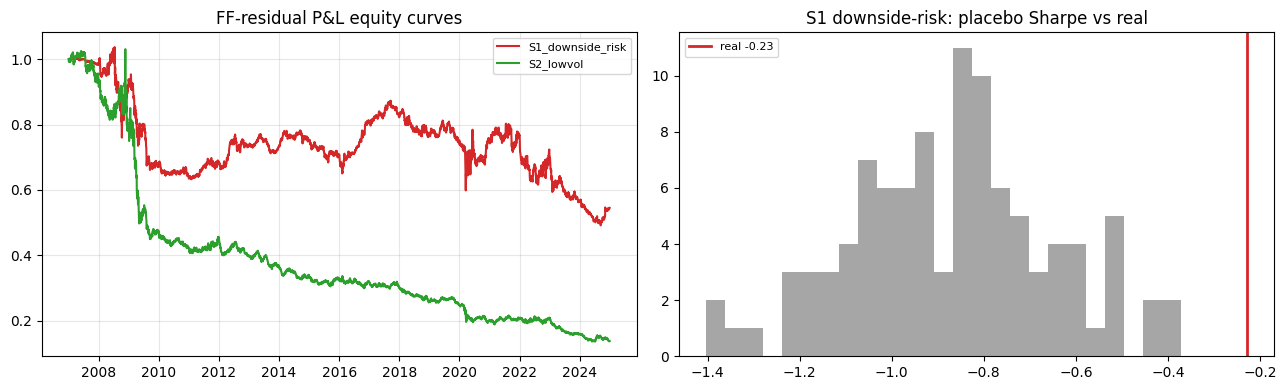

================ HONEST CAVEATS (F0d) ================
 - These are DECLARED hidden-risk harvesters, NOT alpha claims. The test is
   whether the frozen referee flags a profitable-but-risky strategy as H2.
 - S1 sorts on trailing downside-beta-gap; the verdict measures realized-P&L
   tails. Related but out-of-sample, not mechanically identical. The non-trivial
   question is whether S1 also EARNS (passes the luck gate) so the referee faces
   the genuine profitable-but-risky dilemma.
 - Survivorship (current S&P500), linear 10bps costs, DSR approx, beta-only
   residualization, synthetic->real threshold transfer: all as in F0b.
 - Thresholds were calibrated on a market-co-crash archetype; S2_lowvol probes
   whether they generalize to a junk-rally archetype.

F0d pre-registered hidden-risk test complete.


In [10]:
# ============================================================
# 9. Main
# ============================================================
F0D_OUT = run_f0d(CONFIG)
report_f0d(F0D_OUT, CONFIG)
plot_f0d(F0D_OUT, CONFIG)
caveats_f0d(CONFIG)
print('\nF0d pre-registered hidden-risk test complete.')

## 10. What the verdicts mean, and the payoff

**In DEMO mode**, S1→`H2` validates the full H2 path end-to-end: the synthetic-calibrated detector flags a profitable-but-co-crashing strategy as hidden risk, exactly as designed, on the F0 pipeline.

**On real S&P 500 data**, three informative outcomes:
- **S1 → `H2`** (passes luck gate, ≥2 tails fire): the first *real* hidden-risk detection — the synthetic-calibrated referee catching a real downside-risk premium. This is also the precondition that finally makes a **real-data threshold-recalibration split** meaningful (a profitable risky strategy now exists to calibrate against).
- **S1 → `H3`** (does not pass the luck gate): the real downside-risk premium does not survive costs + the deflated-Sharpe hurdle in this universe/period — another conservative-strong null, and a statement that the premium (documented in older/broader samples) is not harvestable in the liquid S&P 500 post-2007 after costs.
- **S2 behavior** probes whether the market-co-crash-tuned tail battery generalizes to the junk-rally archetype, or misses it (the documented archetype-specificity limitation, now tested on real data).

**This is the honest closing move.** Either we see the first real `H2` (the framework closing its loop on real data), or we learn precisely where real hidden-risk premia do and do not live in free equity data — and, via S2, where the tail battery's calibration does and does not generalize. Both are results, not failures. The roadmap is unchanged: point-in-time universe + delisting returns, and — once a profitable real strategy is confirmed — a real-data recalibration split using the V1.3–V1.4 protocol.